Test for using Facebook Prophet to forecast the daily amount of waste

In [48]:
import sys
import os
sys.path.append(os.path.abspath('..'))


import pandas as pd
import numpy as np

from prophet import Prophet
import matplotlib.pyplot as plt
from data_preparation.data_processor import DataProcessor

In [49]:
#waste_data = pd.read_csv("../synthetic_waste_data.csv")
#
#fetcher = DataProcessor(waste_data)
#
#unique_waste = fetcher.waste_data['waste_type'].unique()
#waste_dfs = {}
#
#lags = [6,13,20,21]
#
#for waste in unique_waste:
#    prep_data_company = fetcher.agg_quantity(waste_type=waste, by_waste_type= True)
#    waste_dfs[waste] = fetcher.create_xgboost_features(prep_data_company, lags=lags, lagged_features= True,lagged_ratios= False ,fourier_terms= False, interaction_terms= False).reset_index()
#
#
#for c in range(len(unique_waste)):
#    waste = list(waste_dfs.keys())[c]
#    print(f"Data shape for {waste}:")
#    print(waste_dfs[waste].shape)

In [50]:
waste_data = pd.read_csv("../synthetic_waste_data.csv")

fetcher = DataProcessor(waste_data)

unique_waste = fetcher.waste_data['waste_type'].unique()
waste_dfs = {}


for waste in unique_waste:
    waste_dfs[waste] = fetcher.agg_quantity(waste_type=waste, by_waste_type= True).reset_index().drop(["is_Fall","is_Spring","is_Summer","is_Winter","is_weekend","is_holiday"], axis = 1)
   


for c in range(len(unique_waste)):
    waste = list(waste_dfs.keys())[c]
    print(f"Data shape for {waste}:")
    print(waste_dfs[waste].shape)

Data shape for Municipal:
(1096, 2)
Data shape for Industrial:
(1096, 2)
Data shape for Organic:
(1096, 2)
Data shape for Construction:
(1096, 2)
Data shape for Commercial:
(1096, 2)


In [51]:
#waste_data = pd.read_csv("../synthetic_waste_data.csv")
#
#fetcher = DataProcessor(waste_data)
#
#unique_waste = fetcher.waste_data['company'].unique()
#waste_dfs = {}
#
#
#for waste in unique_waste:
#    waste_dfs[waste] = fetcher.agg_quantity(company=waste, by_company= True).reset_index().drop(["is_Fall","is_Spring","is_Summer","is_Winter","is_weekend","is_holiday"], axis = 1)
#   
#
#
#for c in range(len(unique_waste)):
#    waste = list(waste_dfs.keys())[c]
#    print(f"Data shape for {waste}:")
#    print(waste_dfs[waste].shape)

In [52]:
split_index = int(waste_dfs["Municipal"].shape[0] * 0.8)

def train_and_predict_prophet(df_train, df_test, holidays):
    # Rename columns to match Prophet's expected format
    df_train = df_train.rename(columns={'date': 'ds', 'quantity_tons': 'y'})
    df_test = df_test.rename(columns={'date': 'ds', 'quantity_tons': 'y'})
    
    # Create and train the Prophet model
    model = Prophet(holidays=holidays)
    model.fit(df_train)
    
    # Generate future dates for forecasting
    future_dates = model.make_future_dataframe(periods=len(df_test))  # Forecast for the test period
    
    # Generate forecasts
    forecast = model.predict(future_dates)
    
    return model, forecast

# Define the custom holidays
holidays_base = [
    '2022-01-01',  # New Year
    '2022-12-23', '2022-12-24', '2022-12-25', '2022-12-26', '2022-12-27', '2022-12-28',  # Christmas time
    '2023-01-01',  # New Year
    '2023-12-23', '2023-12-24', '2023-12-25', '2023-12-26', '2023-12-27', '2023-12-28',  # Christmas time
    '2024-01-01',  # New Year
    '2024-12-23', '2024-12-24', '2024-12-25', '2024-12-26', '2024-12-27', '2024-12-28',  # Christmas time
]

# Create a holidays dataframe
holidays = pd.DataFrame({'ds': pd.to_datetime(holidays_base), 'holiday': 'custom_holiday'})

waste_quantity_forecasts = {}

for waste, df in waste_dfs.items():
    # Split the data into train and test sets
    train_data = df[:split_index]
    test_data = df[split_index:]

    # Train and predict using Prophet with custom holidays
    model, forecast = train_and_predict_prophet(train_data, test_data, holidays)
    
    # Store the forecasts for each waste type
    waste_quantity_forecasts[waste] = forecast

17:40:27 - cmdstanpy - INFO - Chain [1] start processing
17:40:27 - cmdstanpy - INFO - Chain [1] done processing
17:40:28 - cmdstanpy - INFO - Chain [1] start processing
17:40:28 - cmdstanpy - INFO - Chain [1] done processing
17:40:29 - cmdstanpy - INFO - Chain [1] start processing
17:40:29 - cmdstanpy - INFO - Chain [1] done processing
17:40:29 - cmdstanpy - INFO - Chain [1] start processing
17:40:29 - cmdstanpy - INFO - Chain [1] done processing
17:40:30 - cmdstanpy - INFO - Chain [1] start processing
17:40:30 - cmdstanpy - INFO - Chain [1] done processing


C:\Users\maxik\AppData\Local\Temp\ipykernel_16816\609681181.py:11: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  test_dates = forecast['ds'].dt.to_pydatetime()[split_index+2:]
C:\Users\maxik\AppData\Local\Temp\ipykernel_16816\609681181.py:11: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  test_dates = forecast['ds'].dt.to_pydatetime()[split_index+2:]
C:\Users\maxik\AppData\Local\Temp\ipykernel_16816\609681181.py:11: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To r

RMSE for Municipal: 51.25
RMSE for Industrial: 40.71
RMSE for Organic: 35.35
RMSE for Construction: 30.67
RMSE for Commercial: 34.79


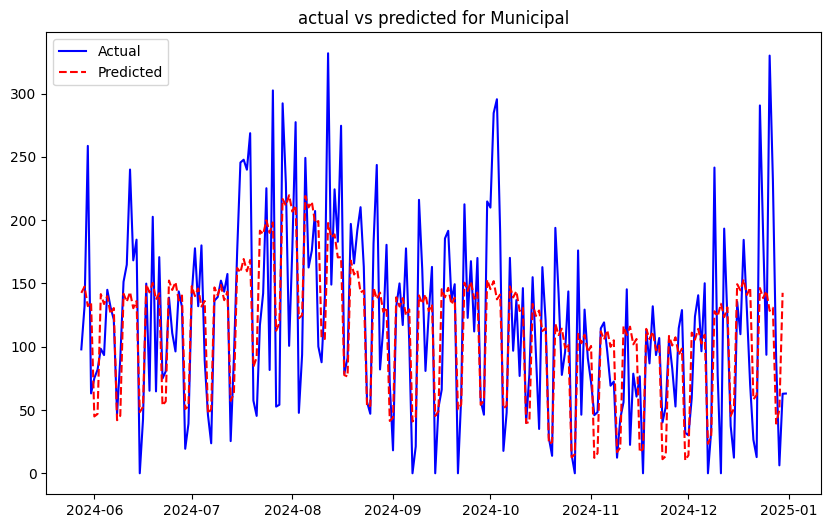

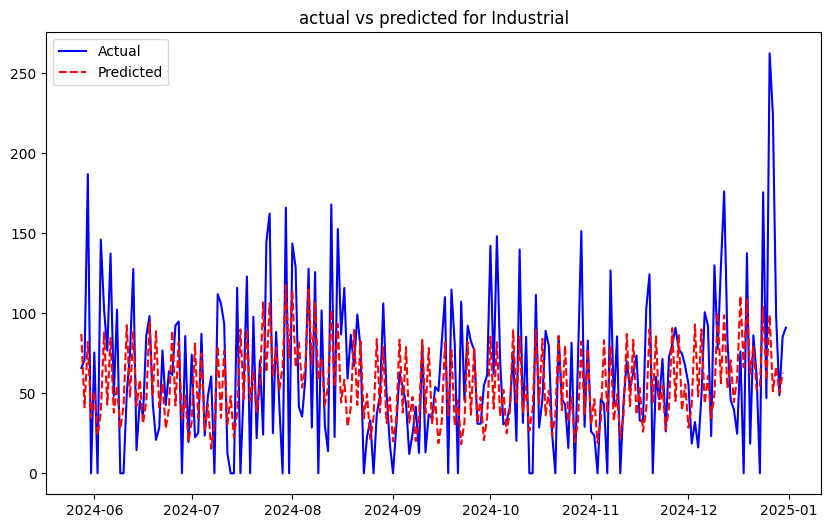

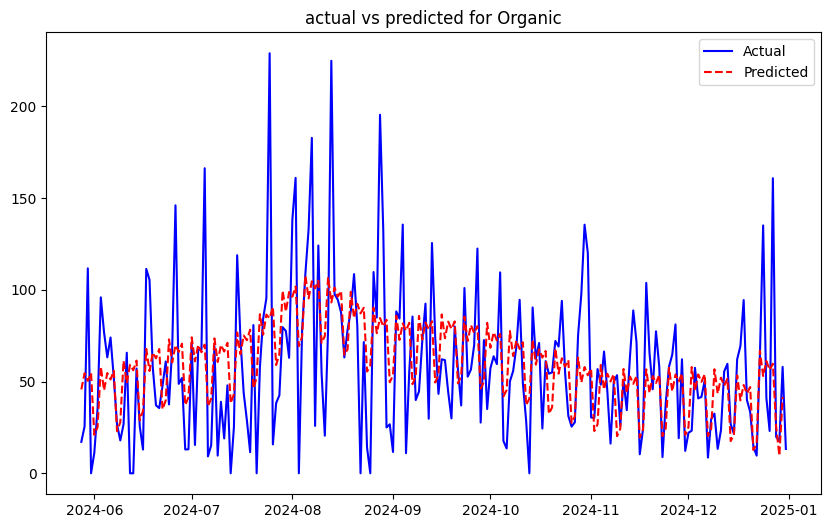

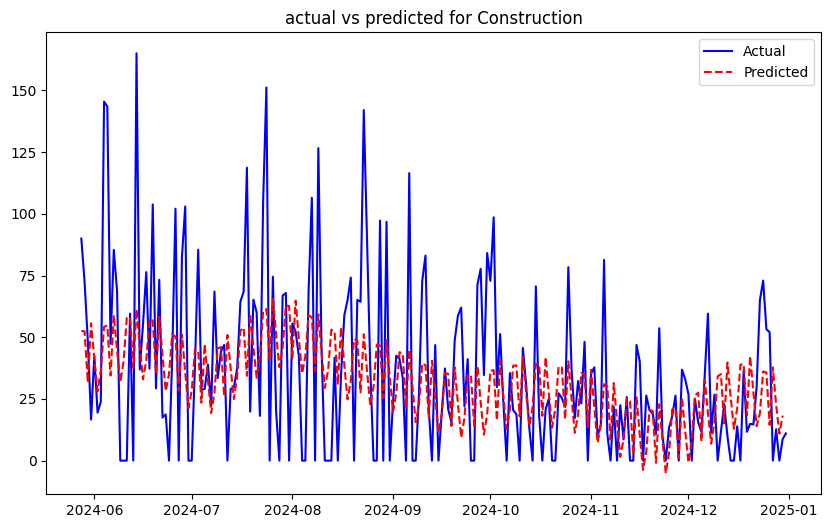

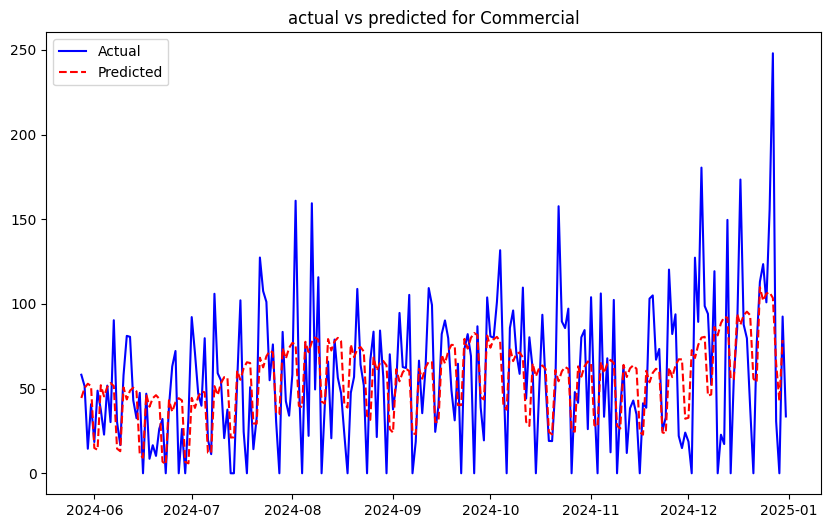

In [57]:
from sklearn.metrics import root_mean_squared_error
for waste, forecast in waste_quantity_forecasts.items():

    # Get the actual values for the test period
    test_actual = waste_dfs[waste]['quantity_tons'].values[split_index+2:]
    
    # Get the predicted values for the test period
    test_predicted = forecast['yhat'].values[split_index+2:]
    
    # Get the dates for the test period
    test_dates = forecast['ds'].dt.to_pydatetime()[split_index+2:]
    rmse = root_mean_squared_error(test_actual, test_predicted)#so it's same lenght as in test_difference
    
    
    # Create a new figure and plot the actual and predicted values for the test set
    plt.figure(figsize=(10, 6))
    plt.plot(test_dates[:], test_actual[:], label='Actual', color = "blue")
    plt.plot(test_dates[:len(test_actual)-1], test_predicted[:len(test_actual)-1], label='Predicted', color = "red", linestyle = "dashed")
    #plt.xlabel('Date')
    #plt.ylabel('Quantity (tons)')
    plt.title(f"actual vs predicted for {waste}")
    plt.legend()
    print(f"RMSE for {waste}: {rmse:.2f}")
    

C:\Users\maxik\AppData\Local\Temp\ipykernel_16816\3623277114.py:12: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  test_dates = forecast['ds'].dt.to_pydatetime()[-len(test_data):]


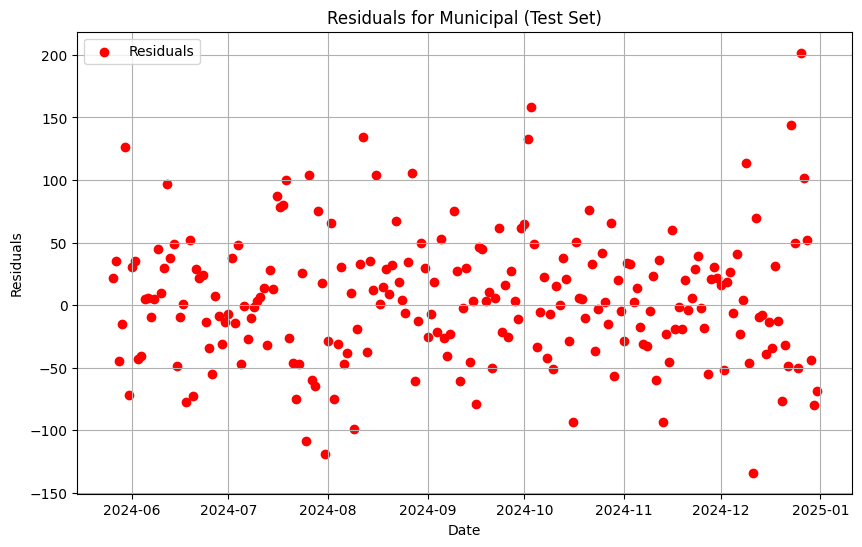

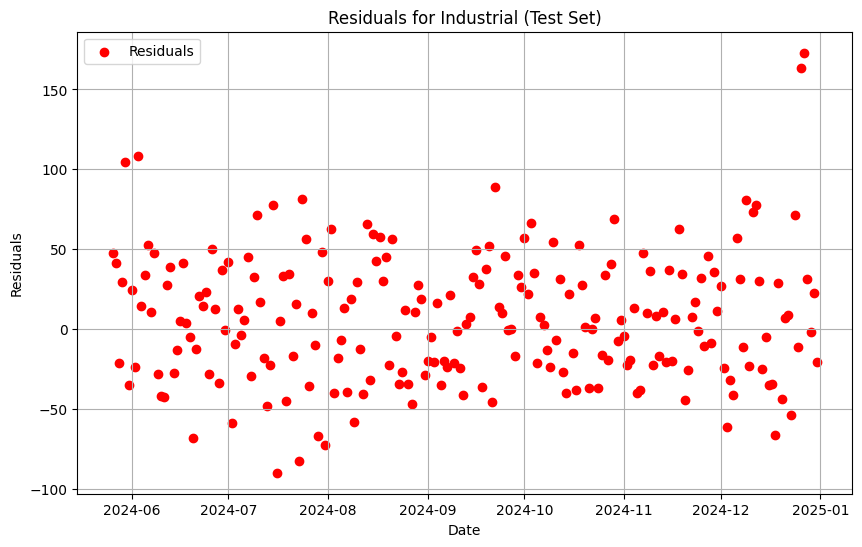

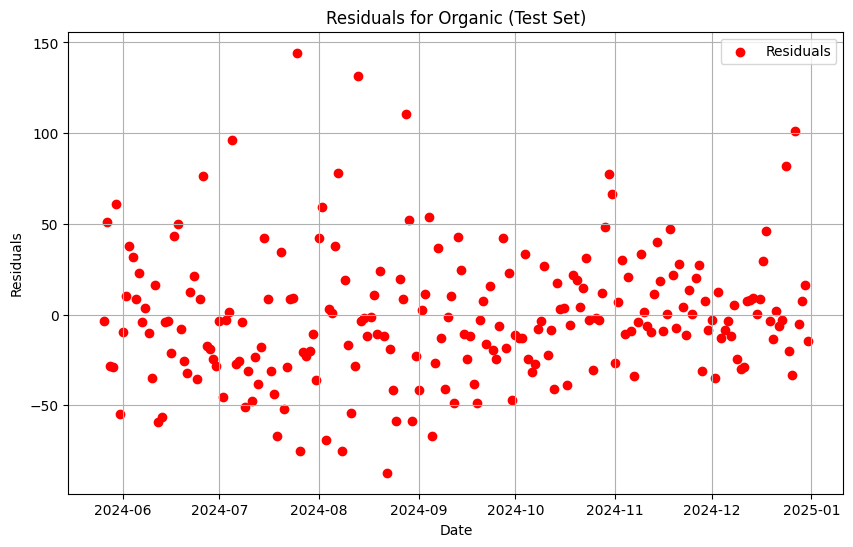

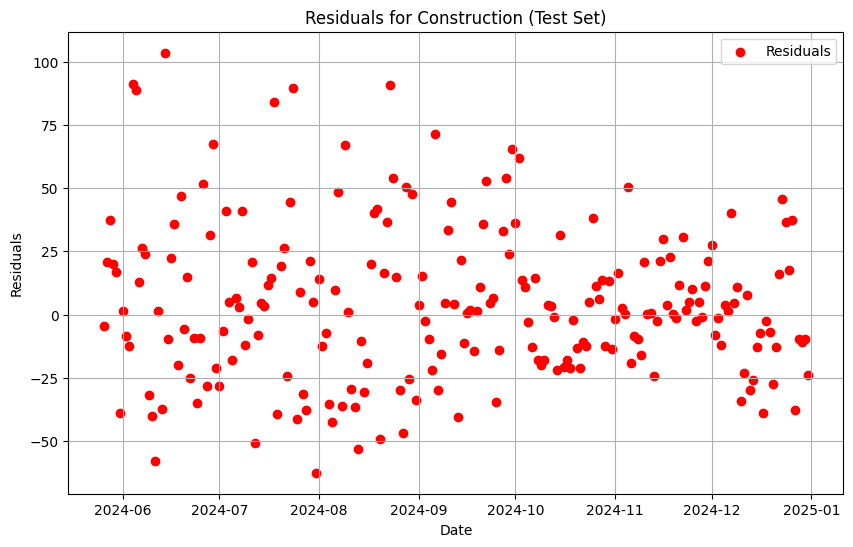

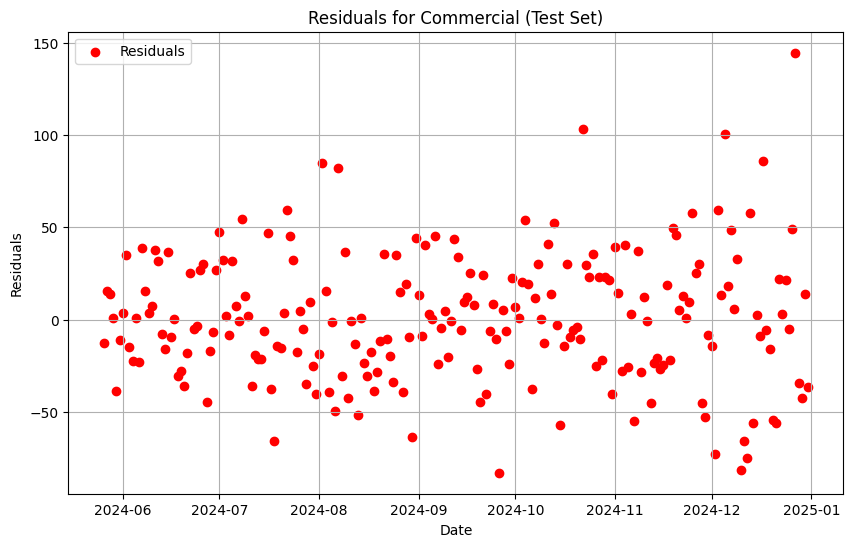

In [55]:
for waste, forecast in waste_quantity_forecasts.items():
    # Get the actual values for the test period
    test_actual = waste_dfs[waste]['quantity_tons'].values[-len(test_data):]
    
    # Get the predicted values for the test period
    test_predicted = forecast['yhat'].values[-len(test_data):]
    
    # Calculate the residuals
    residuals = test_actual - test_predicted
    
    # Get the dates for the test period
    test_dates = forecast['ds'].dt.to_pydatetime()[-len(test_data):]
    
    # Create a new figure for the residuals
    plt.figure(figsize=(10, 6))
    plt.scatter(test_dates, residuals, color='red', label='Residuals')
    plt.xlabel('Date')
    plt.ylabel('Residuals')
    plt.title(f"Residuals for {waste} (Test Set)")
    plt.legend()
    plt.grid(True)
    plt.show()

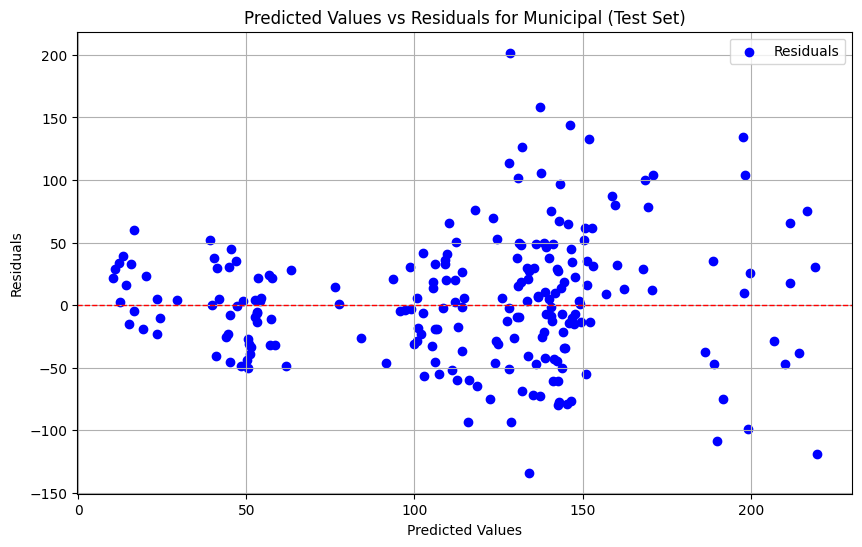

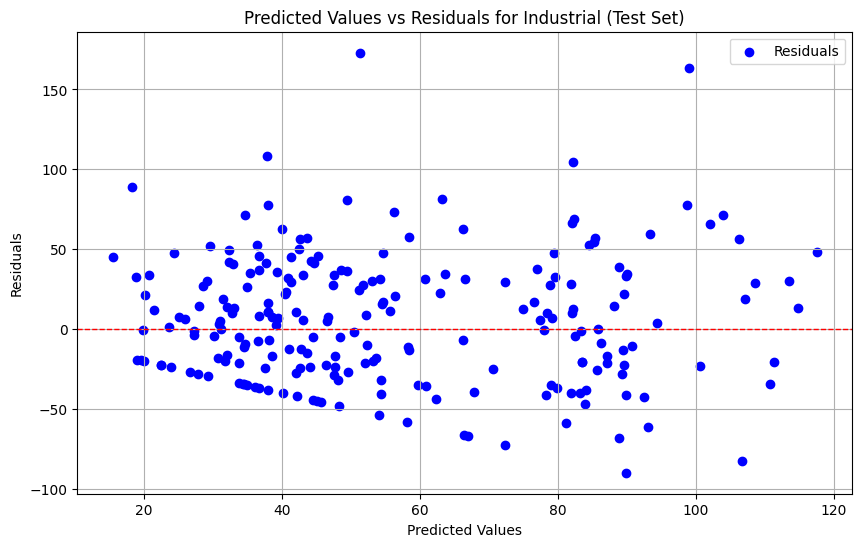

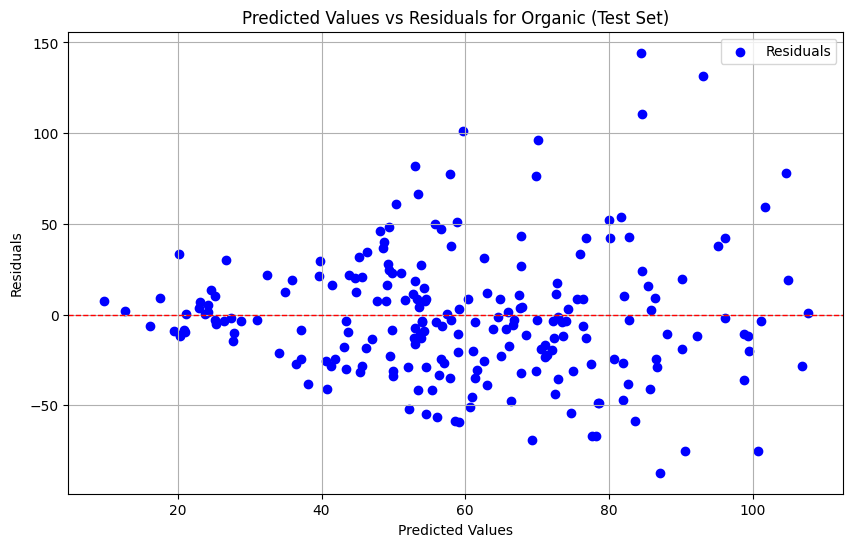

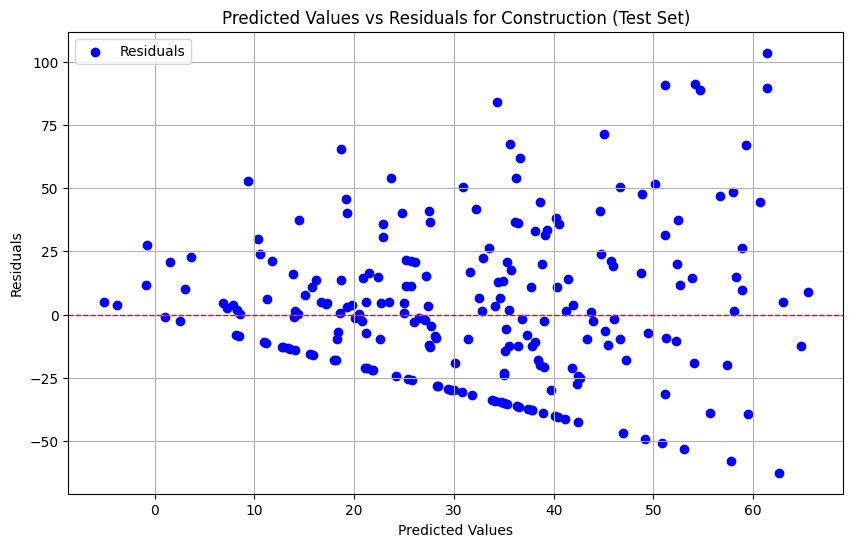

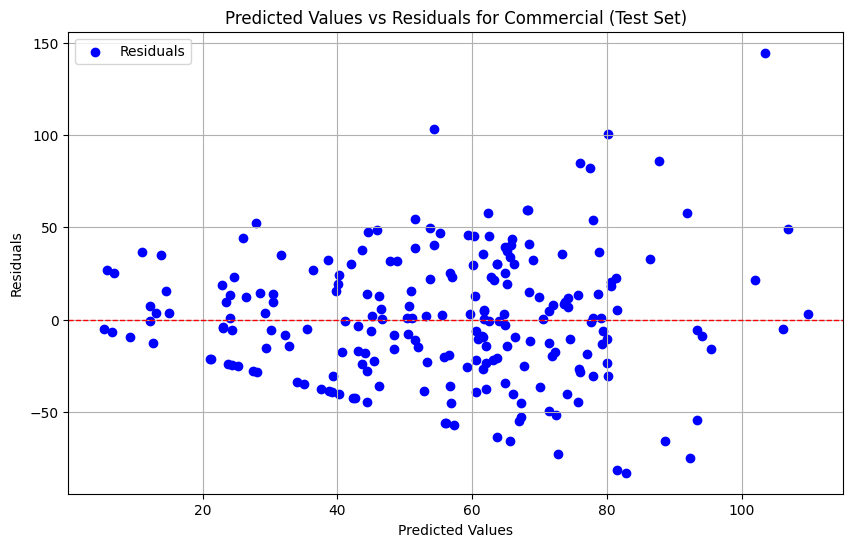

In [56]:
for waste, forecast in waste_quantity_forecasts.items():
    # Get the actual values for the test period
    test_actual = waste_dfs[waste]['quantity_tons'].values[-len(test_data):]
    
    # Get the predicted values for the test period
    test_predicted = forecast['yhat'].values[-len(test_data):]
    
    # Calculate the residuals
    residuals = test_actual - test_predicted
    
    # Create a new figure for the predicted values vs residuals
    plt.figure(figsize=(10, 6))
    plt.scatter(test_predicted, residuals, color='blue', label='Residuals')
    plt.xlabel('Predicted Values')
    plt.ylabel('Residuals')
    plt.title(f"Predicted Values vs Residuals for {waste} (Test Set)")
    plt.legend()
    plt.grid(True)
    
    # Add a horizontal line at y=0 for reference
    plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
    
    plt.show()